# Lab: Agentic Hybrid RAG with Dynamic Routing

In this final capstone lab, we upgrade our LangGraph agent by giving it a "toolbox." 
Instead of forcing every question through a standard vector search, the agent will act as a Router. 
It analyzes the user's question and dynamically decides whether to:
1. Traverse the Neo4j Knowledge Graph (for multi-hop relationships).
2. Query the Vector Index (for semantic meaning).

If the chosen tool fails to find good facts, the agent's critique loop will catch the failure, switch tools, and try again.

In [1]:
!pip install -qU langgraph langchain-openai langchain-huggingface neo4j


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1: Imports & Setup

In [10]:
import os
import json
import requests
from typing import TypedDict, List
from pypdf import PdfReader
from neo4j import GraphDatabase
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

### Step 2: Configure the LLM & Embeddings

In [ ]:
# LLM for routing, grading, and generating
llm = ChatOpenAI(
    openai_api_key="your-api-key",
    openai_api_base="https://openrouter.ai/api/v1",
    model_name="openai/gpt-oss-20b:free",
    temperature=0.0
)

# HuggingFace Embeddings for Vector Search
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

print("LLM and Embedding Models configured successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

LLM and Embedding Models configured successfully!


### Step 3: Connect to Neo4j Database

In [ ]:
NEO4J_URI = "YOUR-NEO4J_URI"
NEO4J_USERNAME = "YOUR-NEO4J_USER"
NEO4J_PASSWORD = "YOUR-NEO4J_PASSWORD"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
print("Connected to Neo4j successfully!")

Connected to Neo4j successfully!


### Step 4: Download PDF and Extract Text

In [13]:
PDF_URL = "https://arxiv.org/pdf/1706.03762.pdf"
PDF_FILENAME = "data/downloaded_paper.pdf"

print(f"Downloading PDF from {PDF_URL}...")
response = requests.get(PDF_URL)
response.raise_for_status()

with open(PDF_FILENAME, "wb") as f:
    f.write(response.content)
print(f"PDF downloaded to {PDF_FILENAME}!")

# Extract text from PDF
reader = PdfReader(PDF_FILENAME)
document_text = ""
for page in reader.pages:
    document_text += page.extract_text() + "\n"
    if len(document_text) >= 1500:
        document_text = document_text[:1500]
        break

print(f"Extracted {len(document_text)} characters of raw document text.")

PDF downloaded to data/downloaded_paper.pdf!
Extracted 1500 characters of raw document text.


### Step 4: Connect to Neo4j & Ingest Graph Data

In [14]:
# 1. Wipe database to guarantee clean state
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
print("Cleared existing Neo4j database.")

Cleared existing Neo4j database.


In [15]:
# 2. Extract Graph Entities via LLM
extract_prompt = f"""
Extract key concepts and their relationships from this text.
Return ONLY a valid JSON object with format:
{{
  "nodes": ["Concept1", "Concept2"],
  "relationships": [
    {{"source": "Concept1", "target": "Concept2", "type": "RELATIONSHIP_TYPE"}}
  ]
}}

Text:
{document_text}
"""
raw_json = llm.invoke(extract_prompt).content.strip()
# Clean markdown backticks if LLM returns ```json ... ```
if raw_json.startswith("```"):
    raw_json = raw_json.split("```")[1]
    if raw_json.startswith("json"):
        raw_json = raw_json[4:]
graph_data = json.loads(raw_json.strip())

In [17]:
# 3. Insert Nodes & Relationships into Neo4j
with driver.session() as session:
    # Merge Nodes
    for node in graph_data.get("nodes", []):
        session.run("MERGE (c:Concept {name: $name})", name=node)
    
    # Merge Relationships
    for rel in graph_data.get("relationships", []):
        rel_type = rel["type"].replace(" ", "_").upper()
        
        # Wrap the relationship type in backticks to safely escape special characters like '.'
        cypher_rel = f"""
        MATCH (a:Concept {{name: $source}}), (b:Concept {{name: $target}})
        MERGE (a)-[r:`{rel_type}`]->(b)
        """
        session.run(cypher_rel, source=rel["source"], target=rel["target"])

print(f"Ingested {len(graph_data.get('nodes', []))} nodes and {len(graph_data.get('relationships', []))} relationships into Neo4j.")

Ingested 35 nodes and 31 relationships into Neo4j.


In [18]:
# 4. Create Vector Index in Neo4j & Embed Nodes
with driver.session() as session:
    session.run("""
    CREATE VECTOR INDEX concept_embeddings IF NOT EXISTS
    FOR (c:Concept) ON (c.embedding)
    OPTIONS {indexConfig: {`vector.dimensions`: 384, `vector.similarity_function`: 'cosine'}}
    """)
    
    # Fetch all concept nodes and generate vector embeddings
    result = session.run("MATCH (c:Concept) RETURN c.name AS name")
    nodes_to_embed = [record["name"] for record in result]
    
    for node_name in nodes_to_embed:
        node_vector = embeddings.embed_query(node_name)
        session.run(
            "MATCH (c:Concept {name: $name}) SET c.embedding = $vector",
            name=node_name, vector=node_vector
        )

print("Neo4j Vector Index created and embeddings populated!")   

Neo4j Vector Index created and embeddings populated!


### Step 5: Define the Agent State

In [19]:
class AgentState(TypedDict):
    question: str               # The active question (may get rewritten)
    current_tool: str           # 'VECTOR' or 'GRAPH'
    retrieved_facts: List[str]  # Chunks/Paths found from Neo4j
    grade: str                  # 'YES' or 'NO'
    retry_count: int            # Safeguard loop counter
    final_answer: str           # Final formatted answer + trace

### Step 6: Router Node

In [20]:
def router_node(state: AgentState) -> AgentState:
    prompt = f"""
    You are an intelligent router. Analyze this question: "{state['question']}"
    
    Which retrieval tool is best suited?
    - VECTOR: Best for general concepts, definitions, or broad semantic meaning.
    - GRAPH: Best for connections, architectural components, relationships, or multi-hop logic.
    
    Reply with ONLY one word: VECTOR or GRAPH.
    """
    
    response = llm.invoke(prompt)
    chosen_tool = response.content.strip().upper()
    
    state["current_tool"] = "GRAPH" if "GRAPH" in chosen_tool else "VECTOR"
    print(f"ROUTER DECISION: Using {state['current_tool']} Tool.")
    return state

### Step 7: Retrieve Node (Tool Execution)

In [21]:
def retrieve_node(state: AgentState) -> AgentState:
    print(f"Retrieving for: '{state['question']}' via {state['current_tool']} Tool")
    question_vector = embeddings.embed_query(state["question"])
    retrieved_data = []

    with driver.session() as session:
        if state["current_tool"] == "GRAPH":
            # Graph Traversal Query
            cypher_query = """
            CALL db.index.vector.queryNodes('concept_embeddings', 2, $vector)
            YIELD node AS seed, score
            MATCH (seed)-[r]-(neighbor:Concept)
            RETURN seed.name + ' --[' + type(r) + ']-> ' + neighbor.name AS path
            LIMIT 5
            """
            results = session.run(cypher_query, vector=question_vector)
            retrieved_data = [record["path"] for record in results]
            
        else: # VECTOR
            # Direct Vector Query on Node Names
            cypher_query = """
            CALL db.index.vector.queryNodes('concept_embeddings', 3, $vector)
            YIELD node AS n, score
            RETURN n.name AS text
            """
            results = session.run(cypher_query, vector=question_vector)
            retrieved_data = [record["text"] for record in results]

    if not retrieved_data:
        retrieved_data = ["No relevant information found in Neo4j."]

    state["retrieved_facts"] = retrieved_data
    return state

### Step 8: Grade Node (Critique Loop)

In [22]:
def grade_node(state: AgentState) -> AgentState:
    facts_text = "\n".join(state["retrieved_facts"])
    
    prompt = f"""
    You are a grading assistant evaluating search results.
    
    Question: {state['question']}
    Retrieved facts:
    {facts_text}

    Do these facts contain ANY relevant hints, keywords, or partial information that could help answer the question?
    Reply with ONLY one word: YES or NO.
    """
    
    response = llm.invoke(prompt)
    raw_grade = response.content.strip().upper()
    
    state["grade"] = "YES" if "YES" in raw_grade else "NO"
    print(f"Grade: {state['grade']}")
    
    return state

### Step 9: Fallback Node (Tool Switch & Query Rewrite)

In [23]:
def fallback_node(state: AgentState) -> AgentState:
    if state["retry_count"] == 0:
        # Switch to the alternative tool on first failure
        old_tool = state["current_tool"]
        state["current_tool"] = "VECTOR" if old_tool == "GRAPH" else "GRAPH"
        print(f"Fallback triggered: Swapping tool from {old_tool} to {state['current_tool']}")
    else:
        # Rewrite the query on second failure
        prompt = f"""
        This question failed to return good search results: "{state['question']}"
        Rewrite it to be clearer and easier to search. Reply with ONLY the new question.
        """
        response = llm.invoke(prompt)
        state["question"] = response.content.strip()
        print(f"Fallback triggered: Rewritten question: {state['question']}")
        
    state["retry_count"] += 1
    return state

### Step 10: Generate Node (With Explainability)

In [24]:
def generate_node(state: AgentState) -> AgentState:
    facts_text = "\n".join(state["retrieved_facts"])
    
    prompt = f"""
    Answer the question using ONLY these facts:
    {facts_text}

    Question: {state['question']}
    
    Output your response in EXACTLY two sections:
    --- FINAL ANSWER ---
    [Give a short, direct answer.]

    --- EXPLAINABILITY ---
    [Briefly summarize the specific facts or paths provided above that you used to construct this answer.]
    """
    
    response = llm.invoke(prompt)
    state["final_answer"] = response.content.strip()
    return state

### Step 11: Build & Compile the LangGraph State Machine

Agentic Hybrid RAG Graph compiled successfully!


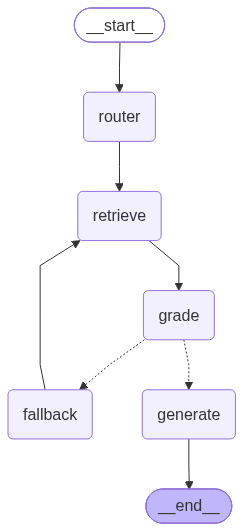

In [25]:
def route_after_grading(state: AgentState) -> str:
    if state["grade"] == "YES" or state["retry_count"] >= 2:
        return "generate"
    return "fallback"

builder = StateGraph(AgentState)

builder.add_node("router", router_node)
builder.add_node("retrieve", retrieve_node)
builder.add_node("grade", grade_node)
builder.add_node("fallback", fallback_node)
builder.add_node("generate", generate_node)

builder.add_edge(START, "router")
builder.add_edge("router", "retrieve")
builder.add_edge("retrieve", "grade")
builder.add_conditional_edges("grade", route_after_grading, {
    "generate": "generate",
    "fallback": "fallback"
})
builder.add_edge("fallback", "retrieve")
builder.add_edge("generate", END)

agent = builder.compile()
print("Agentic Hybrid RAG Graph compiled successfully!")

# Display graph visualization
display(Image(agent.get_graph().draw_mermaid_png()))

### Step 12: Run Test Queries

In [26]:
# Run the pipeline with a multi-hop query to test the router and generation!
test_query = "What models or mechanisms are sequence transduction models based on or connected to?"

result = agent.invoke({
    "question": test_query,
    "current_tool": "",
    "retrieved_facts": [],
    "grade": "",
    "retry_count": 0,
    "final_answer": ""
})

print(f"Total Retries: {result['retry_count']}")

ROUTER DECISION: Using GRAPH Tool.
Retrieving for: 'What models or mechanisms are sequence transduction models based on or connected to?' via GRAPH Tool


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=2, column=13, offset=13>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 13, 'line': 2, 'column': 13}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n            CALL db.index.vector.queryNodes('concept_embeddings', 2, $vector)\n            YIELD node AS seed, score\n            MATCH (seed)-[r]-(neighbor:Concept)\n            RETURN seed.name + ' --[' + type(r) + ']-> ' + neighbor.name AS path\n            LIMIT 5\n            "


Grade: YES
Total Retries: 0


In [27]:
print(result["final_answer"])

--- FINAL ANSWER ---
Sequence transduction models are based on recurrent neural networks and convolutional neural networks, and they use encoder and decoder mechanisms.

--- EXPLAINABILITY ---
The answer is derived from the facts that sequence transduction models are BASED_ON recurrent neural networks and convolutional neural networks, and that they USE an encoder and a decoder. The fact that recurrent neural networks are also BASED_ON sequence transduction models indicates a bidirectional connection between the two.


In [28]:
from yfiles_jupyter_graphs import GraphWidget

# Pull the entire graph we extracted into an interactive widget
with driver.session() as session:
    graph_result = session.run("MATCH (n)-[r]->(m) RETURN n, r, m")
    
    widget = GraphWidget(graph=graph_result.graph())
    display(widget)

GraphWidget(layout=Layout(height='800px', width='100%'))